In [11]:
from netgen.meshing import Mesh as NGMesh, MeshPoint, Element1D, Element0D, Pnt
from ngsolve import *

import matplotlib.pylab as plt
import numpy as np

In [12]:
def poisson_solver(mesh):

    fes = H1(mesh, order=1, dirichlet="left|right|bottom|top")

    u = fes.TrialFunction()
    v = fes.TestFunction()

    f = LinearForm(fes)
    f += 32*(y*(1-y)+x*(1-x))*v*dx

    a = BilinearForm(fes)
    a += InnerProduct(grad(u), grad(v)) * dx

    a.Assemble()
    f.Assemble()  

    solution_gf = GridFunction(fes)
    solution_gf.vec.data = a.mat.Inverse(fes.FreeDofs()) * f.vec

    return solution_gf

In [13]:
def error_L2(solution_gf, exact_cf):
    return sqrt(Integrate((solution_gf - exact_cf)**2, mesh))


def error_H1(error_L2, solution_gf, exact_grad_cf):
    error_H1_semi = sqrt(Integrate((grad(solution_gf) - exact_grad_cf)**2, mesh))

    return sqrt(error_L2**2 + error_H1_semi**2)

In [14]:
exact_cf = 16*x*(1-x)*y*(1-y)

exact_grad_cf_x = exact_cf.Diff(x)
exact_grad_cf_y = exact_cf.Diff(y)
exact_grad_cf = CF((exact_grad_cf_x, exact_grad_cf_y))

h = [0.5, 0.1, 0.05, 0.01, 0.005]

error_L2_vec = np.zeros(len(h))
error_H1_vec = np.zeros(len(h))
iter = 0

for H in h:
    mesh = Mesh(unit_square.GenerateMesh(maxh=H))
    solution_gf = poisson_solver(mesh)
    error_L2_vec[iter] = error_L2(solution_gf, exact_cf)
    error_H1_vec[iter] = error_H1(error_L2_vec[iter], solution_gf, exact_grad_cf)
    
    iter +=1


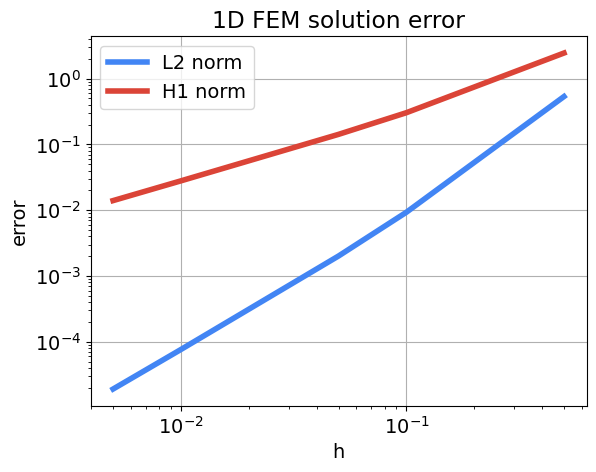

In [15]:
plt.rcParams.update({'font.size': 14})

plt.loglog(h, error_L2_vec, linewidth=4, color='#4285F4', label="L2 norm")
plt.loglog(h, error_H1_vec, linewidth=4, color='#DB4437', label="H1 norm")
plt.xlabel("h")
plt.ylabel("error")
plt.title("1D FEM solution error")
plt.grid()
plt.legend()
plt.legend(frameon=True)
plt.show()